In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 1)) & (dataset.data.index < datetime.datetime(2024, 7, 13)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
bulk = observableClasses.Bulk(dataset, system_name="TGRAD")

Equalizing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]


ValueError: No objects to concatenate

In [5]:
bulk.define_bottom(h0=0, hf=2000)
bulk.define_middle(h0=2000, hf=5000)
bulk.define_top(h0=5000, hf=8000)
bulk.define()

KeyboardInterrupt: 

In [7]:
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pump = systemClasses.System(dataset=dataset, name="PP")
prm = systemClasses.System(dataset=dataset, name="PRM")
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawaii = systemClasses.System(dataset=dataset, name="HAWAI")
pipe.calibrate(calibName="SECOND_POFF_TGRAD_APA_PRM_PIPE_PP_CE_OFF_REC_OFF_HV_OFF_20241203_111500_20251203_113000")
pump.calibrate(calibName="SECOND_POFF_TGRAD_APA_PRM_PIPE_PP_CE_OFF_REC_OFF_HV_OFF_20241203_111500_20251203_113000")
prm.calibrate(calibName="SECOND_POFF_TGRAD_APA_PRM_PIPE_PP_CE_OFF_REC_OFF_HV_OFF_20241203_111500_20251203_113000")
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_APA_PRM_PIPE_PP_CE_OFF_REC_OFF_HV_OFF_20241203_111500_20251203_113000")
hawaii.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Initializing PIPE Sensors:   0%|          | 0/12 [00:00<?, ?sensor/s]

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.99sensor/s]


ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors:   0%|          | 0/12 [00:00<?, ?sensor/s]


ValueError: No objects to concatenate

In [5]:
systems = [pipe, pump, prm, tgrad, hawaii]

NameError: name 'pipe' is not defined

In [6]:
ref_id = 37127
ref_sensor = pump.sensors[ref_id]
results = {}
for system in systems:
    for sensor_id, sensor in system.sensors.items():
        print(f"Processing sensor {sensor_id} in system {system.name}")
        if sensor.id == ref_id:
            continue
        else:
            if "-I" in sensor.name:
                continue
            offset = ref_sensor.data - sensor.data
            deltaX = ref_sensor.X - sensor.X
            deltaY = ref_sensor.Y - sensor.Y
            deltaZ = ref_sensor.Z - sensor.Z
            results[sensor_id] = {
                "mean": offset.mean(),
                "std": offset.std(),
                "sem": offset.sem(),
                "deltaX": deltaX,
                "deltaY": deltaY,
                "deltaZ": deltaZ,
                "X": sensor.X,
                "Y": sensor.Y,
                "Z": sensor.Z,
                "name": sensor.name,
                "system": system.name,
            }
results = pd.DataFrame.from_dict(results, orient='index')


NameError: name 'pump' is not defined

In [ ]:
print(results)

           mean       std       sem  deltaX  deltaY  deltaZ       X       Y  \
39671 -0.012902  0.003331  0.000014  7075.0    71.0 -4983.0  1470.0   186.0   
39631 -0.014475  0.003336  0.000014  4845.0    71.0 -5198.0  3700.0   186.0   
37131 -0.011552  0.003565  0.000014  7075.0    71.0 -2944.0  1470.0   186.0   
39670 -0.004604  0.003460  0.000014  2615.0    71.0 -3159.0  5930.0   186.0   
37136  0.022701  0.003286  0.000013  7075.0    71.0  -924.0  1470.0   186.0   
...         ...       ...       ...     ...     ...     ...     ...     ...   
40019       NaN       NaN       NaN   690.0 -7325.0 -4018.0  7855.0  7582.0   
40020       NaN       NaN       NaN   690.0 -7223.0 -4018.0  7855.0  7480.0   
40021 -0.004898  0.002001  0.000008   690.0 -7122.0 -4018.0  7855.0  7379.0   
40022  0.001792  0.001981  0.000008   690.0 -7020.0 -4018.0  7855.0  7277.0   
40023  0.004480  0.002238  0.000009   690.0 -6918.0 -4018.0  7855.0  7175.0   

            Z     name system  
39671  7223.0      

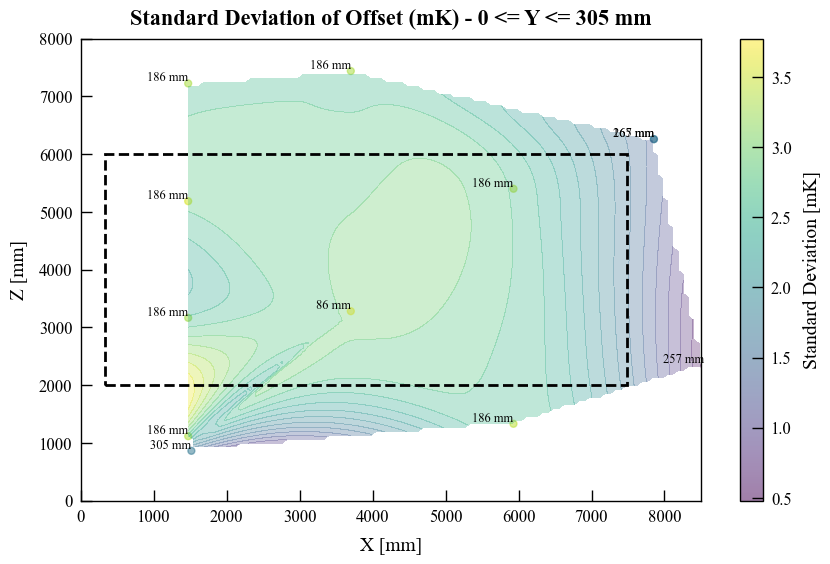

In [ ]:
from scipy.interpolate import griddata

ymin, ymax = 0, 305

# Select points within Y range
mask = (results["Y"] <= ymax) & (results["Y"] >= ymin) #& ~results["system"].str.contains("HAWAI")
x = results.loc[mask, "X"].values
z = results.loc[mask, "Z"].values
std = results.loc[mask, "std"].values * 1000

# Create grid for interpolation
xi = np.linspace(x.min(), x.max(), 100)
zi = np.linspace(z.min(), z.max(), 100)
xi, zi = np.meshgrid(xi, zi)

# Interpolate
std_grid = griddata((x, z), std, (xi, zi), method='cubic')

# Plot original points
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
sc = axes.scatter(x, z, c=std, alpha=0.5, label="Y <= 500 mm")
plt.colorbar(sc, ax=axes, label="Standard Deviation [mK]")

# Plot interpolated surface
contour = axes.contourf(xi, zi, std_grid, levels=20, alpha=0.3, cmap='viridis')
for xi, zi, yi in zip(x, z, results.loc[mask, "Y"].values):
    axes.text(xi, zi, f"{yi:.0f} mm", fontsize=9, ha='right', va='bottom', color='black')

axes.set_xlim(0, 8500)
axes.set_ylim(0, 8000)
axes.set_xlabel("X [mm]")
axes.set_ylabel("Z [mm]")
axes.set_title(f"Standard Deviation of Offset (mK) - {ymin} <= Y <= {ymax} mm")
# Draw only the square resulting from the intersection of the boundary lines
xmin, xmax = 325, 7491
zmin, zmax = 2000, 6000
# Draw rectangle representing the intersection area
rect = plt.Rectangle((xmin, zmin), xmax - xmin, zmax - zmin, fill=False, edgecolor="black", linewidth=2, linestyle="--", label="APA Intersection")
axes.add_patch(rect)

In [5]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

In [220]:
ambient = sensorClasses.Sensor(dataset=dataset, id=1017)

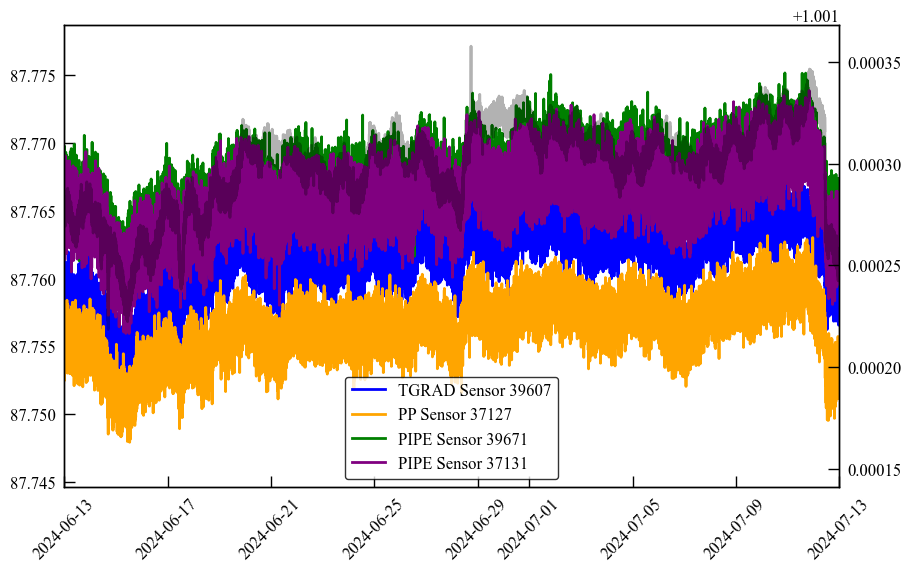

In [224]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data, label="TGRAD Sensor 39607", color="blue")
axes.plot(pump.sensors[37127].data.index, pump.sensors[37127].data, label="PP Sensor 37127", color="orange")
axes.plot(pipe.sensors[39671].data.index, pipe.sensors[39671].data, label="PIPE Sensor 39671", color="green")
axes.plot(pipe.sensors[37131].data.index, pipe.sensors[37131].data, label="PIPE Sensor 37131", color="purple")
axes.legend()
axes.tick_params(axis='x', rotation=45)
axes.set_xlim(pd.Timestamp("2024-06-13"), pd.Timestamp("2024-07-13"))
axes2 = axes.twinx()
axes2.plot(mux1.data.index, mux1.data, label="MUX 4", color="black", alpha=0.3)
# axes2.plot(ambient.data.dropna().index, ambient.data.dropna(), label="Ambient Sensor 1019", color="red", alpha=0.3)

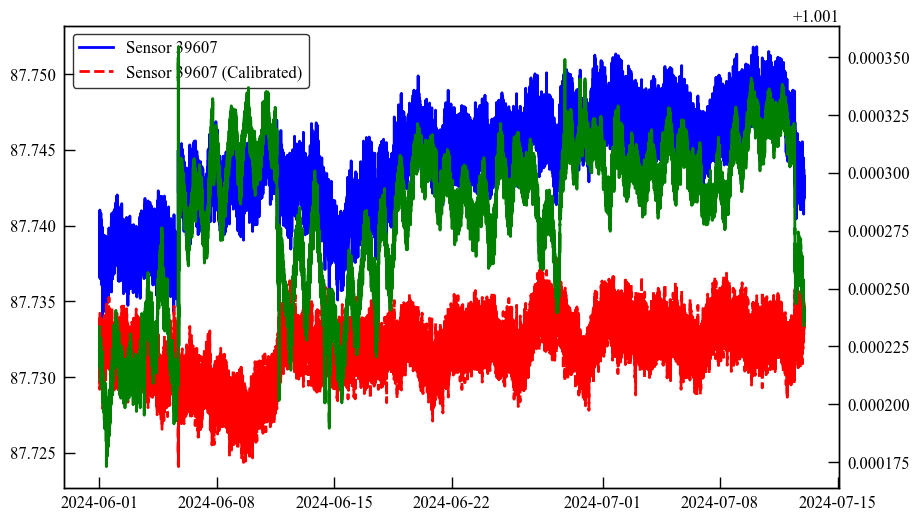

In [6]:
s1 = sensorClasses.Sensor(dataset=dataset, id=39607)
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(s1.data.index, s1.data, label="Sensor 39607", color="blue")
axes2 = axes.twinx()
axes2.plot(mux2.data.index, mux2.data, label="MUX 2", color="green")
axes.plot((s1.data/mux2.data).index, s1.data/mux2.data + 0.1, label="Sensor 39607 (Calibrated)", color="red", linestyle='--')
axes.legend()

Series([], dtype: float64)
Unnamed: 0
2024-06-01 00:01:00   NaN
2024-06-01 00:02:00   NaN
2024-06-01 00:03:00   NaN
2024-06-01 00:04:00   NaN
2024-06-01 00:05:00   NaN
                       ..
2024-07-12 23:55:00   NaN
2024-07-12 23:56:00   NaN
2024-07-12 23:57:00   NaN
2024-07-12 23:58:00   NaN
2024-07-12 23:59:00   NaN
Length: 60479, dtype: float64
Unnamed: 0
2024-06-01 00:01:00   NaN
2024-06-01 00:02:00   NaN
2024-06-01 00:03:00   NaN
2024-06-01 00:04:00   NaN
2024-06-01 00:05:00   NaN
                       ..
2024-07-12 23:55:00   NaN
2024-07-12 23:56:00   NaN
2024-07-12 23:57:00   NaN
2024-07-12 23:58:00   NaN
2024-07-12 23:59:00   NaN
Length: 60479, dtype: float64
Unnamed: 0
2024-06-01 00:01:00   NaN
2024-06-01 00:02:00   NaN
2024-06-01 00:03:00   NaN
2024-06-01 00:04:00   NaN
2024-06-01 00:05:00   NaN
                       ..
2024-07-12 23:55:00   NaN
2024-07-12 23:56:00   NaN
2024-07-12 23:57:00   NaN
2024-07-12 23:58:00   NaN
2024-07-12 23:59:00   NaN
Length: 60479, dtype: 

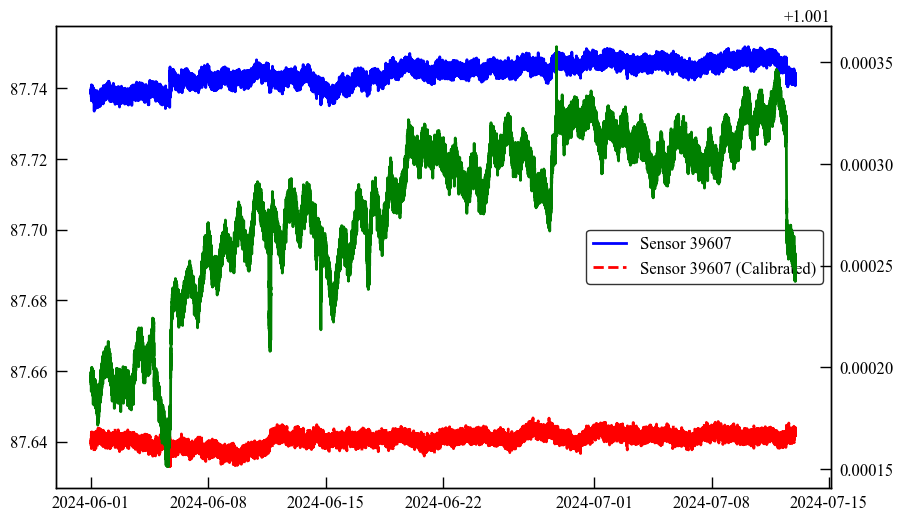

In [7]:
s1 = sensorClasses.Sensor(dataset=dataset, id=39607)
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(s1.data.index, s1.data, label="Sensor 39607", color="blue")
axes2 = axes.twinx()
s1 = s1.muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_APA_PRM_PIPE_PP_CE_OFF_REC_OFF_HV_OFF_20241203_111500_20251203_113000")
print(s1.is_mux_equalized)
axes2.plot(mux1.data.index, mux1.data, label="MUX 1", color="green")
axes.plot((s1.data).index, s1.data, label="Sensor 39607 (Calibrated)", color="red", linestyle='--')
axes.legend()

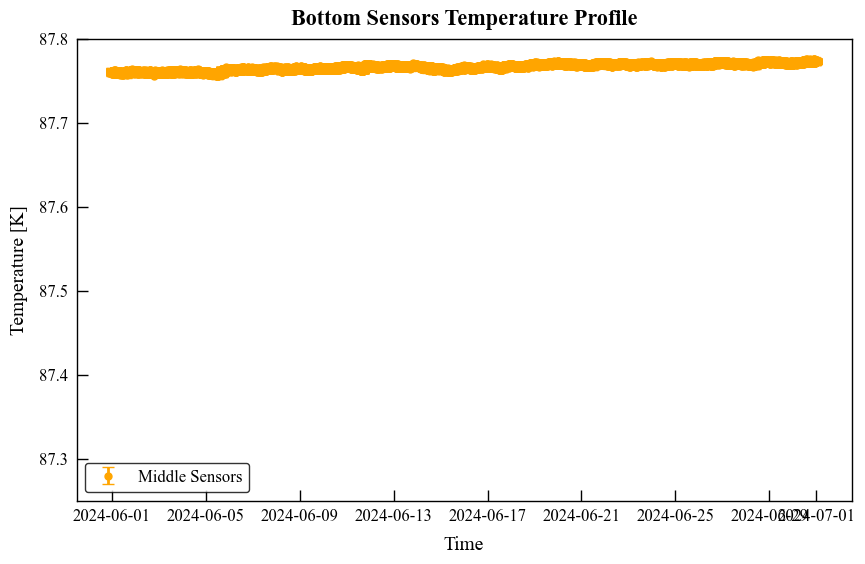

In [135]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
# axes.errorbar(bulk.bottom.index, bulk.bottom['mean'], yerr=bulk.bottom['std'], fmt='o', label="Bottom Sensors", color="blue")
axes.errorbar(bulk.middle.index, bulk.middle['mean'], yerr=bulk.middle['std'], fmt='o', label="Middle Sensors", color="orange")
# axes.errorbar(bulk.top.index, bulk.top['mean'], yerr=bulk.top['std'], fmt='o', label="Top Sensors", color="red")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("Bottom Sensors Temperature Profile")
axes.set_ylim(87.25, 87.8)
axes.legend()

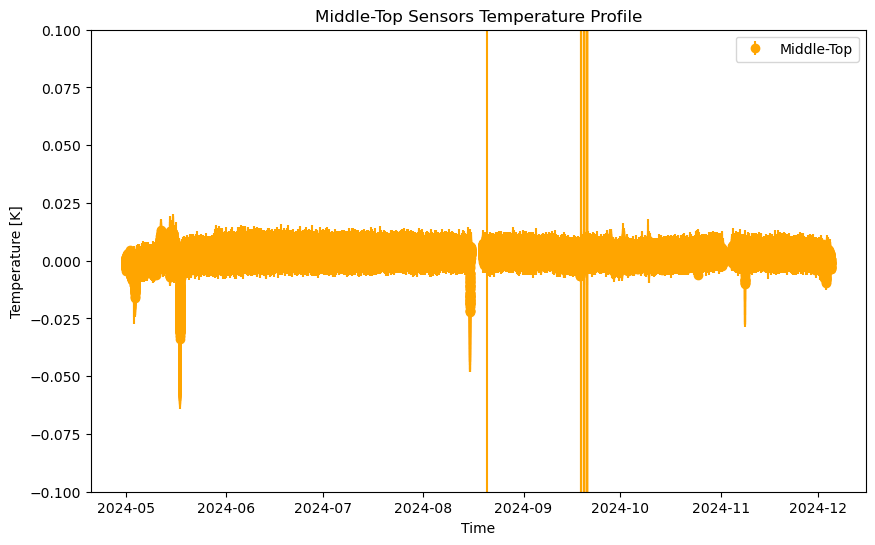

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
# axes.errorbar(bulk.bottom.index, bulk.bottom['mean'], yerr=bulk.bottom['std'], fmt='o', label="Bottom Sensors", color="blue")
axes.errorbar((bulk.middle-bulk.top).index, (bulk.middle-bulk.top)['mean'], yerr=(bulk.middle-bulk.top)['std'], fmt='o', label="Middle-Top", color="orange")
# axes.errorbar(bulk.top.index, bulk.top['mean'], yerr=bulk.top['std'], fmt='o', label="Top Sensors", color="red")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("Middle-Top Sensors Temperature Profile")
axes.set_ylim(-0.1, 0.1)
axes.legend()

Text(0.5, 1.0, 'Horizontal Stability: $\\Delta$X=0.00 m, $\\Delta$Y=0.00 m, $\\Delta$Z=6109.00 m, $\\Delta$=6109.00 m')

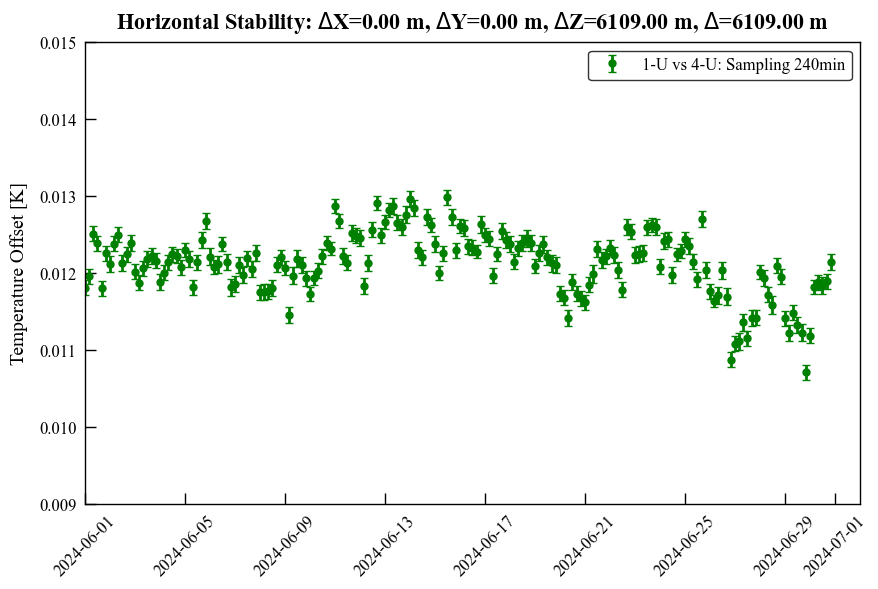

In [141]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
sampling_time = "240min"
s1, s2 = 39671, 39669
axes.set_ylim(0.009, 0.015)
axes.set_xlim(pd.Timestamp("2024-6-1 00:00:00"), pd.Timestamp("2024-7-1 23:59:59"))
axes.tick_params(axis='x', rotation=45)
deltaX = pipe.sensors[s1].X - pipe.sensors[s2].X
deltaZ = pipe.sensors[s1].Z - pipe.sensors[s2].Z
deltaY = pipe.sensors[s1].Y - pipe.sensors[s2].Y
delta = np.sqrt(deltaX**2 + deltaY**2 + deltaZ**2)
axes.errorbar((pipe.sensors[s1].data - pipe.sensors[s2].data).resample(sampling_time).mean().index.values, (pipe.sensors[s1].data - pipe.sensors[s2].data).resample(sampling_time).mean().values, yerr=(pipe.sensors[s1].data - pipe.sensors[s2].data).resample(sampling_time).sem().values, fmt="o", capsize=3,
              label=f"{pipe.sensors[s1].name} vs {pipe.sensors[s2].name}: Sampling {sampling_time}", color="green")
axes.legend()
axes.set_ylabel("Temperature Offset [K]")
axes.set_title(fr"Horizontal Stability: $\Delta$X={deltaX:.2f} m, $\Delta$Y={deltaY:.2f} m, $\Delta$Z={deltaZ:.2f} m, $\Delta$={delta:.2f} m")

In [4]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
apa = systemClasses.System(dataset=dataset, name="APA")

Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 10.48sensor/s]


In [5]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
apa.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.45sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 91.82sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00,  9.53sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 95.94sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 12.49sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 16/16 [00:00<00:00, 99.81sensor/s]


In [6]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)

# Gradient metric

The definition of a metric that defines the stability of the Valencia Temperature Gradient Monitor over time.

Processing timestamps:   0%|          | 0/41 [00:00<?, ?it/s]

Processing timestamps:  17%|█▋        | 7/41 [00:00<00:01, 29.07it/s]

Significant change detected at 2024-06-10 00:00:00, Chi2: 0.94
Significant change detected at 2024-06-10 12:00:00, Chi2: 0.78
Significant change detected at 2024-06-11 00:00:00, Chi2: 0.76


Processing timestamps: 100%|██████████| 41/41 [00:01<00:00, 29.74it/s]


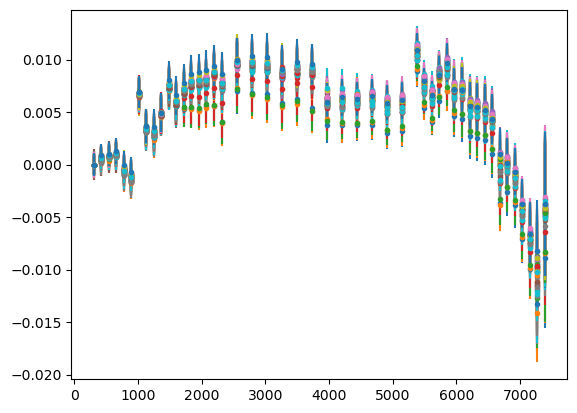

In [32]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 6, 15, 12, 0, 0), tend=datetime.datetime(2024, 6, 15, 13))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".")
ref_profile = tgrad.profiles.copy()
step = 12*60*60
timestamps = pd.date_range(start=datetime.datetime(2024, 6, 10), end=datetime.datetime(2024, 6, 30), freq=f"{step}S")
chi2_series = []
anomalies = []
chi2_threshold = 0.5 # Define a threshold for significant change
for timestamp in tqdm(timestamps, desc="Processing timestamps"):
    current_profile = tgrad.makeProfiles(tini=timestamp, tend=timestamp + datetime.timedelta(seconds=step))
    plt.errorbar(current_profile.profiles["Y"].values, current_profile.profiles["temp"].values -  current_profile.profiles["temp"].loc[(current_profile.profiles["Y"]==305)].values[0], yerr=current_profile.profiles["err"].values, fmt=".", label=f"{timestamp}")
    if len(current_profile.profiles) != len(ref_profile):
        continue
    # Combine errors from current_profile and ref_profile in quadrature
    combined_err = np.sqrt(current_profile.profiles["err"].values**2 + ref_profile["err"].values**2)
    # reduced chi2
    # Normalize both profiles to the temperature at Y==305
    y_norm = 305
    ref_temp_norm = ref_profile.loc[ref_profile["Y"] == y_norm, "temp"].values[0]
    curr_temp_norm = current_profile.profiles.loc[current_profile.profiles["Y"] == y_norm, "temp"].values[0]
    # Calculate normalized temperature arrays
    ref_temp_normed = ref_profile["temp"].values - ref_temp_norm
    curr_temp_normed = current_profile.profiles["temp"].values - curr_temp_norm
    # Compute reduced chi2 between normalized profiles
    chi2 = np.sum(((curr_temp_normed - ref_temp_normed) / combined_err) ** 2) / (len(curr_temp_normed) - 1)
    chi2_series.append((timestamp, chi2))
    if chi2 > chi2_threshold:
        print(f"Significant change detected at {timestamp}, Chi2: {chi2:.2f}")
        anomalies.append((timestamp, current_profile.profiles.copy()))

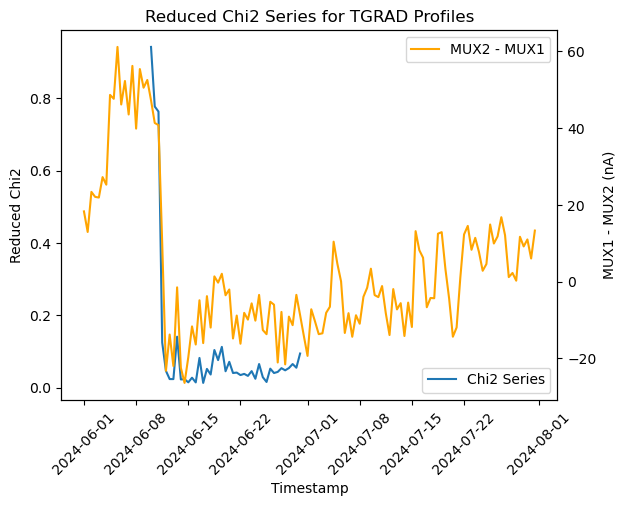

In [33]:
fig, axes = plt.subplots(1,1)
df_chi2 = pd.DataFrame(chi2_series, columns=["timestamp", "chi2"])
df_chi2 = df_chi2.set_index("timestamp")
axes.plot(df_chi2.index.values, df_chi2["chi2"].values, label="Chi2 Series")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Timestamp")
axes.set_ylabel("Reduced Chi2")
axes.set_title("Reduced Chi2 Series for TGRAD Profiles")
axes2 = axes.twinx()
axes2.plot(mux1.data.loc[(mux1.data.index<datetime.datetime(2024, 8, 1))].resample("12h").mean().index.values,
           -1e6*(mux1.data.loc[(mux1.data.index<datetime.datetime(2024, 8, 1))].resample("12h").mean() - mux2.data.loc[(mux1.data.index<datetime.datetime(2024, 8, 1))].resample("12h").mean()).values,
           label="MUX2 - MUX1", color="orange")
# axes2.set_ylim(-100, 100)
axes2.set_ylabel("MUX1 - MUX2 (nA)")
axes2.legend(loc="upper right")
axes.legend(loc="lower right")

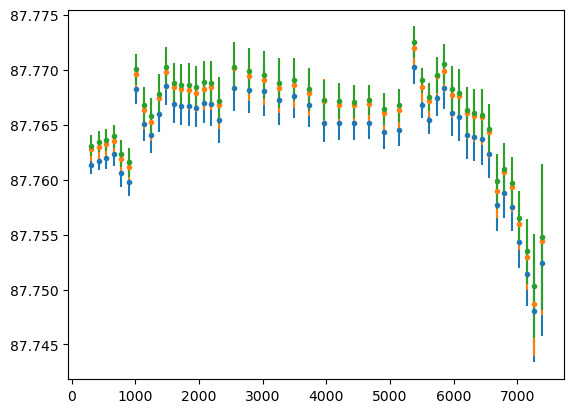

In [34]:
for timestamp, profile in anomalies:
    plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt=".", label=f"{timestamp}")
# plt.legend()
plt.show()

In [35]:
timestamps = pd.date_range(start="2024-11-20 12:00:00", end="2024-11-29 12:00:00", freq="D")
print(timestamps)

DatetimeIndex(['2024-11-20 12:00:00', '2024-11-21 12:00:00',
               '2024-11-22 12:00:00', '2024-11-23 12:00:00',
               '2024-11-24 12:00:00', '2024-11-25 12:00:00',
               '2024-11-26 12:00:00', '2024-11-27 12:00:00',
               '2024-11-28 12:00:00', '2024-11-29 12:00:00'],
              dtype='datetime64[ns]', freq='D')


2024-11-20 12:00:00 2024-11-20 12:01:00 2024-11-20 13:00:00


KeyError: 'Y'

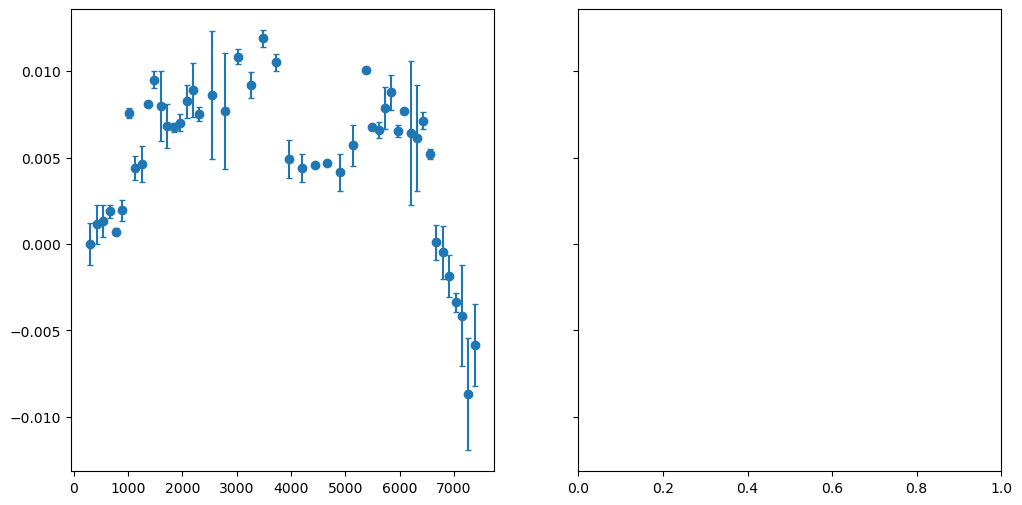

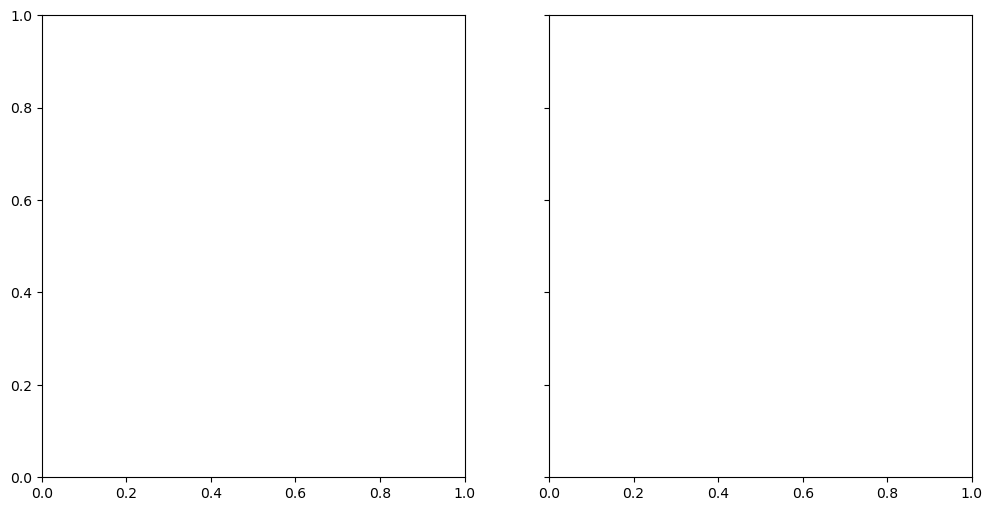

In [37]:
profiles_list = []

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for tini in timestamps:
    tend_short = tini + datetime.timedelta(minutes=1)
    tend_long = tini + datetime.timedelta(minutes=60)
    print(tini, tend_short, tend_long)
    ##############################################################################
    tgrad.makeProfiles(tini=tini, tend=tend_short)
    hawai.makeProfiles(tini=tini, tend=tend_short)
    # Create a temporary profile DataFrame for the short duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # Add a column for timestamp and duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # profiles_list.append(temp_profile_short)
    axes[0].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[0].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==1107)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################
    # Create a temporary profile DataFrame for the long duration
    tgrad.makeProfiles(tini=tini, tend=tend_long)
    hawai.makeProfiles(tini=tini, tend=tend_long)
    # Create a temporary profile DataFrame for the long duration
    temp_profile_long = hawai.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    # Add a column for timestamp and duration
    temp_profile_long = tgrad.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    profiles_list.append(temp_profile_long)
    axes[1].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[1].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==1107)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################

# Merge all profiles into a single DataFrame
# Merge all profiles in profiles_list on the 'Y' column, keeping only rows with matching 'Y' values
merged_profiles = profiles_list[0][["Y"]].copy()
for i, df in enumerate(profiles_list):
    merged_profiles = merged_profiles.merge(
        df[["Y", "temp"]].rename(columns={"temp": f"temp_{i}"}),
        on="Y",
        how="inner"
    )
axes[0].legend(ncol=2)
axes[1].legend(ncol=2)
axes[0].set_title("Calculated over 1 minute")
axes[1].set_title("Calculated over 60 minutes")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_xlabel("Y [m]")
axes[1].set_xlabel("Y [m]")
fig.tight_layout()

axes2[0].legend(ncol=2)
axes2[1].legend(ncol=2)
axes2[0].set_title("Calculated over 1 minute")
axes2[1].set_title("Calculated over 60 minutes")
axes2[0].set_ylabel("Temperature [K]")
axes2[0].set_xlabel("Y [m]")
axes2[1].set_xlabel("Y [m]")
fig2.tight_layout()

In [68]:
merged_profiles = merged_profiles.set_index("Y")
merged_temps = merged_profiles.mean(axis=1)
merged_errors = merged_profiles.std(axis=1)

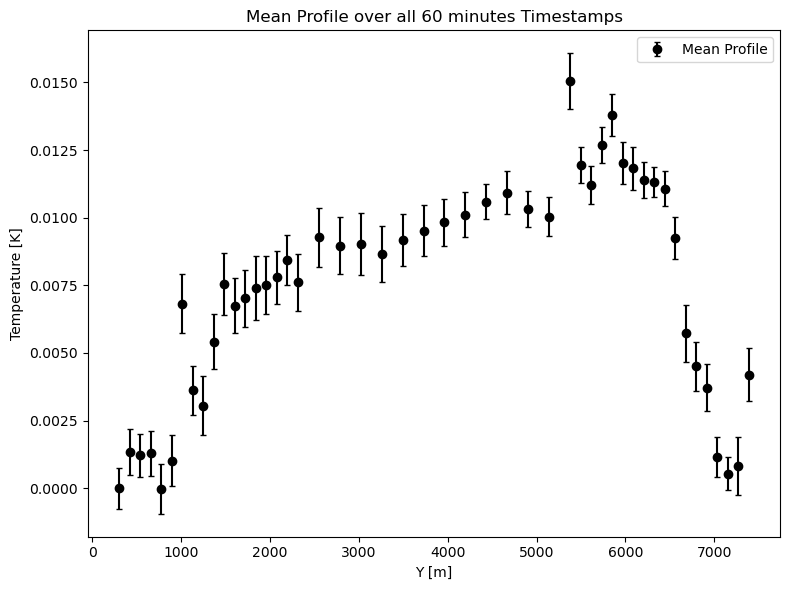

In [80]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)
axes.errorbar(
    merged_profiles.index.values,
    (merged_temps - merged_temps.loc[305]).values,
    yerr=merged_errors,
    fmt='o',
    label='Mean Profile',
    color='black',
    capsize=2.5)
axes.set_title("Mean Profile over all 60 minutes Timestamps")
axes.set_ylabel("Temperature [K]")
axes.set_xlabel("Y [m]")
axes.legend()
fig.tight_layout()

In [23]:
timestamps = pd.date_range(start="2024-5-5 12:00:00", end="2024-5-14 12:00:00", freq="D")
print(timestamps)

DatetimeIndex(['2024-05-05 12:00:00', '2024-05-06 12:00:00',
               '2024-05-07 12:00:00', '2024-05-08 12:00:00',
               '2024-05-09 12:00:00', '2024-05-10 12:00:00',
               '2024-05-11 12:00:00', '2024-05-12 12:00:00',
               '2024-05-13 12:00:00', '2024-05-14 12:00:00'],
              dtype='datetime64[ns]', freq='D')


2024-05-05 12:00:00 2024-05-05 12:01:00 2024-05-05 13:00:00
2024-05-06 12:00:00 2024-05-06 12:01:00 2024-05-06 13:00:00
2024-05-07 12:00:00 2024-05-07 12:01:00 2024-05-07 13:00:00
2024-05-08 12:00:00 2024-05-08 12:01:00 2024-05-08 13:00:00
2024-05-09 12:00:00 2024-05-09 12:01:00 2024-05-09 13:00:00
2024-05-10 12:00:00 2024-05-10 12:01:00 2024-05-10 13:00:00
2024-05-11 12:00:00 2024-05-11 12:01:00 2024-05-11 13:00:00
2024-05-12 12:00:00 2024-05-12 12:01:00 2024-05-12 13:00:00
2024-05-13 12:00:00 2024-05-13 12:01:00 2024-05-13 13:00:00
2024-05-14 12:00:00 2024-05-14 12:01:00 2024-05-14 13:00:00


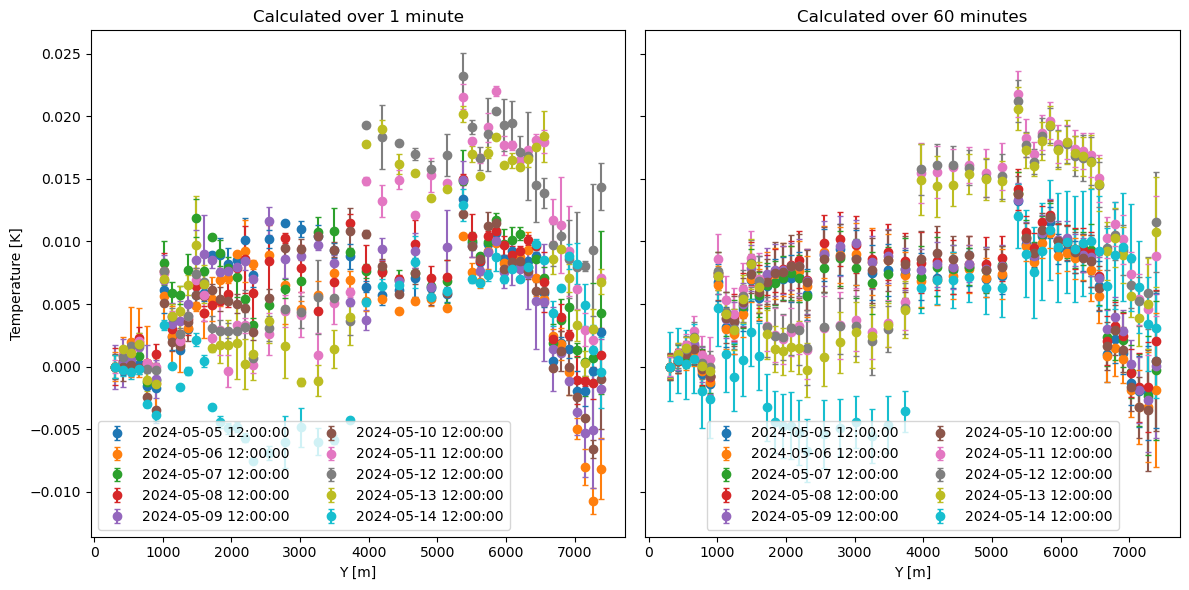

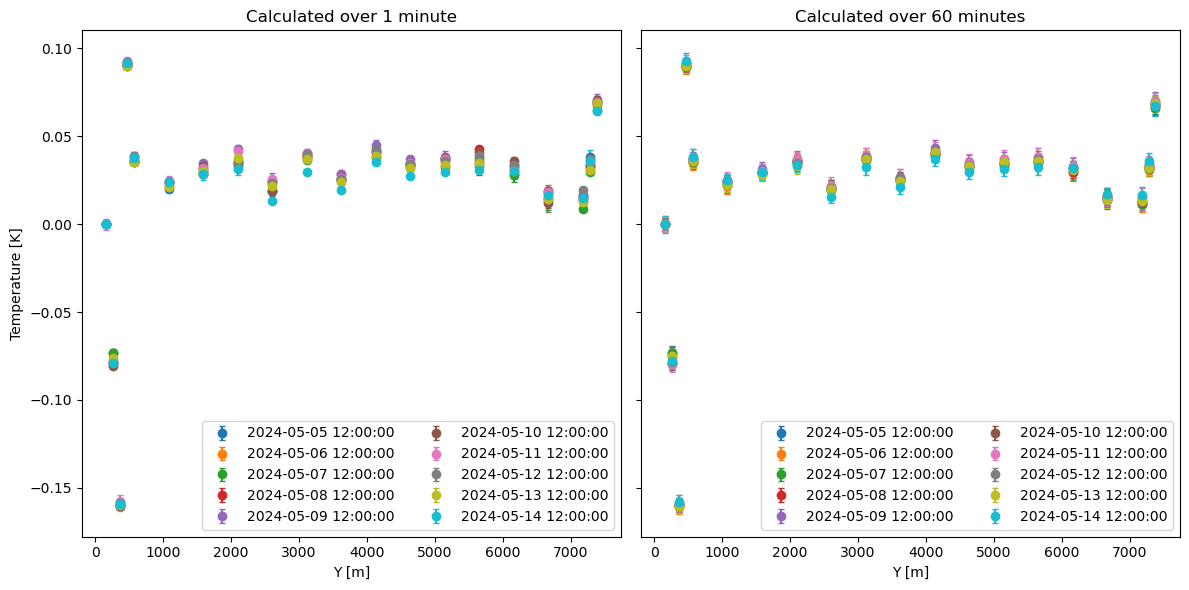

In [25]:
profiles_list = []
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for tini in timestamps:
    tend_short = tini + datetime.timedelta(minutes=1)
    tend_long = tini + datetime.timedelta(minutes=60)
    print(tini, tend_short, tend_long)
    ##############################################################################
    tgrad.makeProfiles(tini=tini, tend=tend_short)
    hawai.makeProfiles(tini=tini, tend=tend_short)
    # Create a temporary profile DataFrame for the short duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # Add a column for timestamp and duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # profiles_list.append(temp_profile_short)
    axes[0].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[0].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==165)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################
    # Create a temporary profile DataFrame for the long duration
    tgrad.makeProfiles(tini=tini, tend=tend_long)
    hawai.makeProfiles(tini=tini, tend=tend_long)
    # Create a temporary profile DataFrame for the long duration
    temp_profile_long = hawai.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    # Add a column for timestamp and duration
    temp_profile_long = tgrad.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    profiles_list.append(temp_profile_long)
    axes[1].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[1].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==165)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################

# Merge all profiles into a single DataFrame
# Merge all profiles in profiles_list on the 'Y' column, keeping only rows with matching 'Y' values
merged_profiles = profiles_list[0][["Y"]].copy()
for i, df in enumerate(profiles_list):
    merged_profiles = merged_profiles.merge(
        df[["Y", "temp"]].rename(columns={"temp": f"temp_{i}"}),
        on="Y",
        how="inner"
    )
axes[0].legend(ncol=2)
axes[1].legend(ncol=2)
axes[0].set_title("Calculated over 1 minute")
axes[1].set_title("Calculated over 60 minutes")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_xlabel("Y [m]")
axes[1].set_xlabel("Y [m]")
fig.tight_layout()

axes2[0].legend(ncol=2)
axes2[1].legend(ncol=2)
axes2[0].set_title("Calculated over 1 minute")
axes2[1].set_title("Calculated over 60 minutes")
axes2[0].set_ylabel("Temperature [K]")
axes2[0].set_xlabel("Y [m]")
axes2[1].set_xlabel("Y [m]")
fig2.tight_layout()